<a href="https://colab.research.google.com/github/Sarasii22/Broadband-Fraud-Management-System/blob/main/model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas pyarrow

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_parquet(
    "/content/drive/MyDrive/Intern/dataset.parquet"
)

In [4]:
df.head()

,subscriber_id,record_opening_time,record_closing_time,cc_total_octets_bytes,cc_input_octets_bytes,cc_output_octets_bytes,load_date
0,SUB_365EECB8,2026-05-16 11:00:00,2026-05-16 10:00:00,0,8094,0,2026-05-17 05:04:50
1,SUB_18F7320C,2026-05-16 11:00:00,2026-05-16 10:00:00,0,104908831,3101465,2026-05-17 05:04:50
2,SUB_291441E6,2026-05-16 11:00:00,2026-05-16 10:00:00,0,1265702,0,2026-05-17 05:04:50
3,SUB_DF3164B0,2026-05-16 11:00:00,2026-05-16 10:00:00,0,11306,0,2026-05-17 05:04:50
4,SUB_A7EA0B37,2026-05-16 11:00:00,2026-05-16 10:00:00,0,104970480,576504,2026-05-17 05:04:50


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2700000 entries, 0 to 2699999
Data columns (total 7 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   subscriber_id           object        
 1   record_opening_time     datetime64[ns]
 2   record_closing_time     datetime64[ns]
 3   cc_total_octets_bytes   int64         
 4   cc_input_octets_bytes   int64         
 5   cc_output_octets_bytes  int64         
 6   load_date               datetime64[ns]
dtypes: datetime64[ns](3), int64(3), object(1)
memory usage: 144.2+ MB


In [6]:
df.shape

(2700000, 7)

check null and duplicates

In [7]:
df.isnull().sum()

,0
subscriber_id,0
record_opening_time,0
record_closing_time,0
cc_total_octets_bytes,0
cc_input_octets_bytes,0
cc_output_octets_bytes,0
load_date,0


In [8]:
df.duplicated().sum()

np.int64(18627)

In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(2681373, 7)

Bytes to MB

In [11]:
# Convert bytes to MB
df["download_mb"] = df["cc_input_octets_bytes"] / (1024 * 1024)
df["upload_mb"] = df["cc_output_octets_bytes"] / (1024 * 1024)

# Calculate total usage in MB
df["total_usage_mb"] = df["download_mb"] + df["upload_mb"]

# Display the new columns
print(df[[
    "cc_input_octets_bytes",
    "cc_output_octets_bytes",
    "download_mb",
    "upload_mb",
    "total_usage_mb"
]].head())

   cc_input_octets_bytes  cc_output_octets_bytes  download_mb  upload_mb  \
0                   8094                       0     0.007719   0.000000   
1              104908831                 3101465   100.048858   2.957788   
2                1265702                       0     1.207067   0.000000   
3                  11306                       0     0.010782   0.000000   
4              104970480                  576504   100.107651   0.549797   

   total_usage_mb  
0        0.007719  
1      103.006645  
2        1.207067  
3        0.010782  
4      100.657448  


In [12]:
print("="*50)
print("Dataset Shape")
print("="*50)
print(df.shape)

print("\n")
print("="*50)
print("Column Names")
print("="*50)
print(df.columns.tolist())

print("\n")
print("="*50)
print("Data Types")
print("="*50)
print(df.dtypes)

print("\n")
print("="*50)
print("Missing Values")
print("="*50)
print(df.isnull().sum())

Dataset Shape
(2681373, 10)


Column Names
['subscriber_id', 'record_opening_time', 'record_closing_time', 'cc_total_octets_bytes', 'cc_input_octets_bytes', 'cc_output_octets_bytes', 'load_date', 'download_mb', 'upload_mb', 'total_usage_mb']


Data Types
subscriber_id                     object
record_opening_time       datetime64[ns]
record_closing_time       datetime64[ns]
cc_total_octets_bytes              int64
cc_input_octets_bytes              int64
cc_output_octets_bytes             int64
load_date                 datetime64[ns]
download_mb                      float64
upload_mb                        float64
total_usage_mb                   float64
dtype: object


Missing Values
subscriber_id             0
record_opening_time       0
record_closing_time       0
cc_total_octets_bytes     0
cc_input_octets_bytes     0
cc_output_octets_bytes    0
load_date                 0
download_mb               0
upload_mb                 0
total_usage_mb            0
dtype: int64


In [13]:
print("Unique Subscribers:", df["subscriber_id"].nunique())

Unique Subscribers: 512705


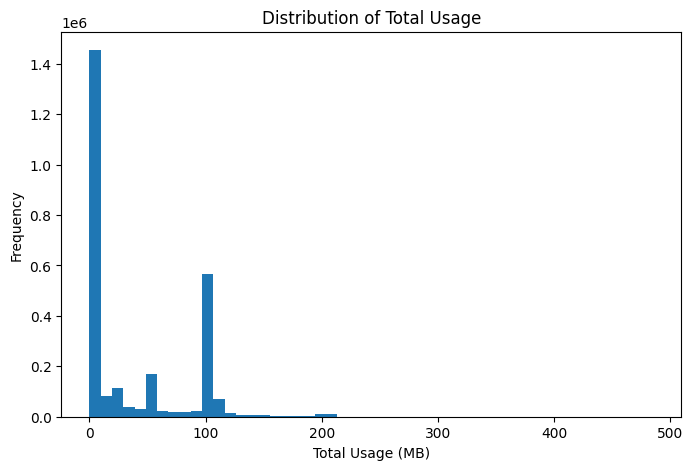

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["total_usage_mb"], bins=50)
plt.xlabel("Total Usage (MB)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Usage")
plt.show()

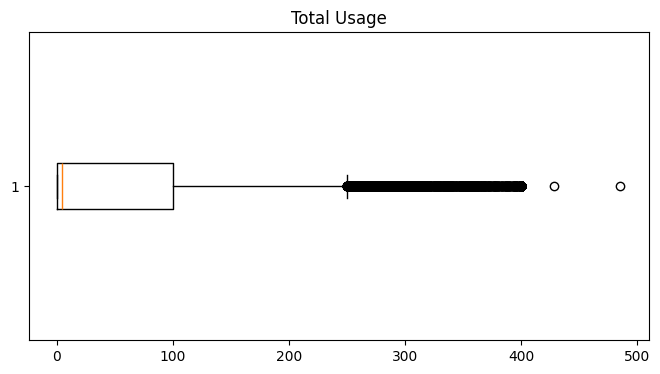

In [15]:
plt.figure(figsize=(8,4))
plt.boxplot(df["total_usage_mb"], vert=False)
plt.title("Total Usage")
plt.show()

In [16]:
print(df["total_usage_mb"].quantile([
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]))

0.50      4.662180
0.75    100.006155
0.90    103.836155
0.95    107.497655
0.99    195.741616
Name: total_usage_mb, dtype: float64


In [17]:
print(df[[
    "download_mb",
    "upload_mb"
]].describe())

        download_mb     upload_mb
count  2.681373e+06  2.681373e+06
mean   2.664529e+01  1.129129e+01
std    4.347087e+01  2.702518e+01
min    0.000000e+00  0.000000e+00
25%    0.000000e+00  5.340576e-05
50%    7.771120e-01  5.600185e-01
75%    5.000711e+01  3.740119e+00
max    4.135383e+02  4.853148e+02


In [18]:
daily_usage = (
    df.groupby(["subscriber_id", "load_date"])["total_usage_mb"]
      .sum()
)

print(daily_usage.describe())

count    512705.000000
mean        198.402821
std         440.213781
min           0.000028
25%           3.465756
50%         100.006887
75%         232.323649
max       72096.349815
Name: total_usage_mb, dtype: float64


In [19]:
sessions = (
    df.groupby("subscriber_id")
      .size()
)

print(sessions.describe())

count    512705.000000
mean          5.229855
std           8.232371
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max        4358.000000
dtype: float64


In [20]:
subscriber_profile = df.groupby("subscriber_id").agg(

    total_download_mb = ("download_mb","sum"),
    total_upload_mb = ("upload_mb","sum"),
    total_usage_mb = ("total_usage_mb","sum"),
    avg_usage_mb = ("total_usage_mb", 'mean'),
    max_usage_mb = ("total_usage_mb", "max"),
    Number_of_sessions = ("record_opening_time","count")


)

In [21]:
#disable scientific notation

pd.set_option('display.float_format', '{:.5f}'.format)

In [22]:
subscriber_profile

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions
subscriber_id,,,,,,
SUB_00000326,11.27373,54.40195,65.67568,10.94595,50.00805,6
SUB_00001E72,4.90480,0.00000,4.90480,2.45240,4.83538,2
SUB_000048C2,31.77706,700.49108,732.26814,43.07460,100.13471,17
SUB_0000573D,0.19353,0.06723,0.26077,0.05215,0.06518,5
SUB_00005906,26.34410,39.26876,65.61286,21.87095,51.28535,3
...,...,...,...,...,...,...
SUB_FFFFA359,3.76679,0.96731,4.73410,2.36705,4.70216,2
SUB_FFFFD0A0,5.64014,102.81592,108.45606,36.15202,102.81592,3
SUB_FFFFD502,0.53010,1.00559,1.53569,0.25595,0.36524,6


count how many records have the closing time after the opening time:

In [23]:
count = (df["record_closing_time"] > df["record_opening_time"]).sum()
print("closing time > Opening time ", count)

closing time > Opening time  1986834


In [24]:
count = (df["record_closing_time"] < df["record_opening_time"]).sum()
print("closing time < Opening time ", count)

closing time < Opening time  603869


In [25]:
subscriber_profile.info()

<class 'pandas.core.frame.DataFrame'>
Index: 512705 entries, SUB_00000326 to SUB_FFFFEC62
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   total_download_mb   512705 non-null  float64
 1   total_upload_mb     512705 non-null  float64
 2   total_usage_mb      512705 non-null  float64
 3   avg_usage_mb        512705 non-null  float64
 4   max_usage_mb        512705 non-null  float64
 5   Number_of_sessions  512705 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 27.4+ MB


In [26]:
subscriber_profile.describe().T

,count,mean,std,min,25%,50%,75%,max
total_download_mb,512705.00000,139.35103,382.06225,0.00000,0.57344,9.40920,151.56271,70929.99216
total_upload_mb,512705.00000,59.05179,153.45248,0.00000,0.66416,8.14599,63.97125,18006.26569
total_usage_mb,512705.00000,198.40282,440.21378,0.00003,3.46576,100.00689,232.32365,72096.34982
avg_usage_mb,512705.00000,32.17013,35.80360,0.00003,1.19462,20.11507,51.82163,400.00350
max_usage_mb,512705.00000,61.78268,56.45666,0.00003,2.46464,53.09980,102.55655,485.31480
Number_of_sessions,512705.00000,5.22986,8.23237,1.00000,2.00000,4.00000,7.00000,4358.00000


In [27]:
subscriber_profile.corr()

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions
total_download_mb,1.00000,0.20697,0.94005,0.47744,0.39918,0.43949
total_upload_mb,0.20697,1.00000,0.52822,0.21272,0.30677,0.36413
total_usage_mb,0.94005,0.52822,1.00000,0.48852,0.45339,0.50836
avg_usage_mb,0.47744,0.21272,0.48852,1.00000,0.79059,0.10232
max_usage_mb,0.39918,0.30677,0.45339,0.79059,1.00000,0.20803
Number_of_sessions,0.43949,0.36413,0.50836,0.10232,0.20803,1.00000


Scale features

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(subscriber_profile)
X_scaled.shape

(512705, 6)

In [29]:
X_scaled

array([[-0.33522658, -0.03030155, -0.3015064 , -0.5927953 , -0.20856084,
         0.09355086],
       [-0.35189648, -0.38482173, -0.43955509, -0.83002151, -1.00869157,
        -0.39233638],
       [-0.28156165,  4.18005584,  1.21274222,  0.30456356,  0.67931868,
         1.42974078],
       ...,
       [-0.36334673, -0.37826863, -0.44720846, -0.89136886, -1.08786991,
         0.09355086],
       [-0.3183343 ,  1.68309253,  0.31042007,  0.27124674,  0.67996714,
         0.33649448],
       [-0.34099569, -0.2025317 , -0.36655048, -0.75071739, -0.61246951,
         0.21502267]])

### ISOLATION FOREST

In [30]:
#Start with 1% contamination. This means we assume about 1% of subscribers are anomalous.
from sklearn.ensemble import IsolationForest
iso_model = IsolationForest(
    n_estimators = 200, #number of trees
    contamination = 0.01, #assume About 1% of subscribers are suspicious.
    random_state = 42
)

iso_model.fit(X_scaled)

IsolationForest(contamination=0.01, n_estimators=200, random_state=42)

Predict anomalies

In [31]:
#binary prediction
subscriber_profile["anomaly_label"] = (
    iso_model.predict(X_scaled) == -1  # convertd into normal = 0, anomaly = 1 (default normal = 1, anomaly = -1)
).astype(int)

In [32]:
subscriber_profile["anomaly_label"].value_counts()

,count
anomaly_label,
0,507577
1,5128


raw anomaly scores

(gives every subscriber a raw anomaly score)

In [33]:
anomaly_score = iso_model.score_samples(X_scaled)

In [34]:
subscriber_profile["anomaly_score"] = anomaly_score
subscriber_profile.sort_values(
    by = "anomaly_score"
)

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions,anomaly_label,anomaly_score
subscriber_id,,,,,,,,
SUB_40280E69,19434.90010,8595.65512,28030.55521,189.39564,353.37566,148,1,-0.85069
SUB_EAE3453C,16553.97234,2982.13378,19536.10613,174.42952,382.67315,112,1,-0.84926
SUB_B6FE9A56,16214.20581,2113.53176,18327.73757,226.26837,276.17664,81,1,-0.84639
SUB_ABCA6F82,4775.82015,5769.71187,10545.53203,251.08410,390.49311,42,1,-0.84239
SUB_EC6F5F03,6355.17072,4315.77975,10670.95047,150.29508,196.26308,71,1,-0.83983
...,...,...,...,...,...,...,...,...
SUB_ABC12A52,0.09413,0.54302,0.63715,0.31857,0.42113,2,0,-0.35707
SUB_4D9D4C9C,0.10154,0.48168,0.58322,0.29161,0.47665,2,0,-0.35707
SUB_5FC4DA4E,0.09488,0.53405,0.62893,0.31446,0.39580,2,0,-0.35707


Normalize the scores
(Min - Max scalling - 0 - 1)
0 - anomaly, 1 - normal

In [35]:
from sklearn.preprocessing import MinMaxScaler

score_scaler = MinMaxScaler()

isolation_scores = score_scaler.fit_transform(
    anomaly_score.reshape(-1,1)
)

In [36]:
# Reverse the Scale (By default, Higher score = More Normal)
subscriber_profile["isolation_score"] = 1 - isolation_scores.ravel()

In [37]:
# Create Status
subscriber_profile["ml_status"] = subscriber_profile["anomaly_label"].map({
    0: "Normal",
    1: "Anomaly"
})

In [38]:
subscriber_profile = subscriber_profile.sort_values(
    by="isolation_score",
    ascending=False
)

subscriber_profile.head(20)

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions,anomaly_label,anomaly_score,isolation_score,ml_status
subscriber_id,,,,,,,,,,
SUB_40280E69,19434.90010,8595.65512,28030.55521,189.39564,353.37566,148,1,-0.85069,1.00000,Anomaly
SUB_EAE3453C,16553.97234,2982.13378,19536.10613,174.42952,382.67315,112,1,-0.84926,0.99709,Anomaly
SUB_B6FE9A56,16214.20581,2113.53176,18327.73757,226.26837,276.17664,81,1,-0.84639,0.99128,Anomaly
SUB_ABCA6F82,4775.82015,5769.71187,10545.53203,251.08410,390.49311,42,1,-0.84239,0.98318,Anomaly
SUB_EC6F5F03,6355.17072,4315.77975,10670.95047,150.29508,196.26308,71,1,-0.83983,0.97800,Anomaly
SUB_3D65F467,7760.78605,7584.27242,15345.05847,139.50053,197.03898,110,1,-0.83926,0.97685,Anomaly
SUB_454E0855,6653.16687,7646.68475,14299.85163,137.49857,204.83915,104,1,-0.83926,0.97685,Anomaly
SUB_9CD351BA,5479.73368,4076.10055,9555.83423,156.65302,198.98306,61,1,-0.83841,0.97512,Anomaly
SUB_F4DFBA4F,6745.14501,4077.21471,10822.35972,144.29813,196.99562,75,1,-0.83841,0.97512,Anomaly


In [39]:
print(subscriber_profile["isolation_score"].describe())

count   512705.00000
mean         0.14163
std          0.13618
min          0.00000
25%          0.04969
50%          0.11038
75%          0.17607
max          1.00000
Name: isolation_score, dtype: float64


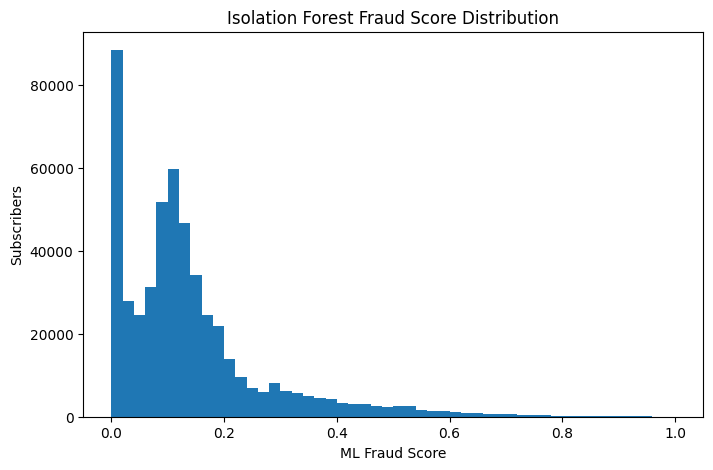

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    subscriber_profile["isolation_score"],
    bins=50
)

plt.xlabel("ML Fraud Score")
plt.ylabel("Subscribers")
plt.title("Isolation Forest Fraud Score Distribution")

plt.show()

save model

In [41]:
import joblib

# Save the trained Isolation Forest model
joblib.dump(iso_model, "isolation_forest_model.pkl")

print("Isolation Forest model saved successfully!")

Isolation Forest model saved successfully!


Save the StandardScaler

In [42]:
joblib.dump(scaler, "standard_scaler.pkl")

print("StandardScaler saved successfully!")

StandardScaler saved successfully!


Save the MinMaxScaler

In [43]:
joblib.dump(score_scaler, "score_scaler.pkl")

print("Score scaler saved successfully!")

Score scaler saved successfully!


In [44]:
import os

print(os.getcwd())

/content


In [45]:
!ls

drive			    sample_data       standard_scaler.pkl
isolation_forest_model.pkl  score_scaler.pkl


Download pkl files

In [46]:
from google.colab import files

files.download("isolation_forest_model.pkl")
files.download("standard_scaler.pkl")
files.download("score_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Local Outlier Factor (LOF)

In [47]:
from sklearn.neighbors import LocalOutlierFactor
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01,
    novelty=True
)

lof_model.fit(X_scaled)

LocalOutlierFactor(contamination=0.01, novelty=True)

In [48]:
subscriber_profile["lof_label"] = (
    lof_model.predict(X_scaled) == -1
).astype(int)

In [49]:
lof_raw_score = lof_model.score_samples(X_scaled)

subscriber_profile["lof_raw_score"] = lof_raw_score

In [50]:
from sklearn.preprocessing import MinMaxScaler

lof_scaler = MinMaxScaler()

lof_scores = lof_scaler.fit_transform(
    lof_raw_score.reshape(-1,1)
)

subscriber_profile["lof_score"] = 1 - lof_scores.ravel()

In [51]:
subscriber_profile["lof_status"] = subscriber_profile["lof_label"].map({
    0:"Normal",
    1:"Anomaly"
})

In [52]:
subscriber_profile

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions,anomaly_label,anomaly_score,isolation_score,ml_status,lof_label,lof_raw_score,lof_score,lof_status
subscriber_id,,,,,,,,,,,,,,
SUB_40280E69,19434.90010,8595.65512,28030.55521,189.39564,353.37566,148,1,-0.85069,1.00000,Anomaly,0,-1.07217,0.00000,Normal
SUB_EAE3453C,16553.97234,2982.13378,19536.10613,174.42952,382.67315,112,1,-0.84926,0.99709,Anomaly,0,-0.96620,0.00000,Normal
SUB_B6FE9A56,16214.20581,2113.53176,18327.73757,226.26837,276.17664,81,1,-0.84639,0.99128,Anomaly,0,-0.99094,0.00000,Normal
SUB_ABCA6F82,4775.82015,5769.71187,10545.53203,251.08410,390.49311,42,1,-0.84239,0.98318,Anomaly,0,-0.97949,0.00000,Normal
SUB_EC6F5F03,6355.17072,4315.77975,10670.95047,150.29508,196.26308,71,1,-0.83983,0.97800,Anomaly,1,-2.79354,0.00005,Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SUB_5FC4DA4E,0.09488,0.53405,0.62893,0.31446,0.39580,2,0,-0.35707,0.00039,Normal,0,-1.02916,0.00000,Normal
SUB_4D9D4C9C,0.10154,0.48168,0.58322,0.29161,0.47665,2,0,-0.35707,0.00039,Normal,0,-1.04494,0.00000,Normal
SUB_ABC12A52,0.09413,0.54302,0.63715,0.31857,0.42113,2,0,-0.35707,0.00039,Normal,0,-1.15263,0.00001,Normal


In [53]:
import joblib

joblib.dump(lof_model,"lof_model.pkl")
joblib.dump(lof_scaler,"lof_score_scaler.pkl")

['lof_score_scaler.pkl']

In [54]:
from google.colab import files

files.download("lof_model.pkl")
files.download("lof_score_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## One-Class SVM

In [55]:
from sklearn.svm import OneClassSVM
svm_model = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.01
)

svm_model.fit(X_scaled)

OneClassSVM(nu=0.01)

In [56]:
subscriber_profile["svm_label"] = (
    svm_model.predict(X_scaled) == -1
).astype(int)

In [57]:
svm_raw_score = svm_model.score_samples(X_scaled)

subscriber_profile["svm_raw_score"] = svm_raw_score

In [58]:
svm_scaler = MinMaxScaler()

svm_scores = svm_scaler.fit_transform(
    svm_raw_score.reshape(-1,1)
)

subscriber_profile["svm_score"] = 1 - svm_scores.ravel()

In [59]:
subscriber_profile["svm_status"] = subscriber_profile["svm_label"].map({
    0:"Normal",
    1:"Anomaly"
})

In [60]:
subscriber_profile

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions,anomaly_label,anomaly_score,isolation_score,ml_status,lof_label,lof_raw_score,lof_score,lof_status,svm_label,svm_raw_score,svm_score,svm_status
subscriber_id,,,,,,,,,,,,,,,,,,
SUB_40280E69,19434.90010,8595.65512,28030.55521,189.39564,353.37566,148,1,-0.85069,1.00000,Anomaly,0,-1.07217,0.00000,Normal,0,257.09700,0.10354,Normal
SUB_EAE3453C,16553.97234,2982.13378,19536.10613,174.42952,382.67315,112,1,-0.84926,0.99709,Anomaly,0,-0.96620,0.00000,Normal,0,231.93293,0.19163,Normal
SUB_B6FE9A56,16214.20581,2113.53176,18327.73757,226.26837,276.17664,81,1,-0.84639,0.99128,Anomaly,0,-0.99094,0.00000,Normal,0,243.97369,0.14948,Normal
SUB_ABCA6F82,4775.82015,5769.71187,10545.53203,251.08410,390.49311,42,1,-0.84239,0.98318,Anomaly,0,-0.97949,0.00000,Normal,0,236.49889,0.17565,Normal
SUB_EC6F5F03,6355.17072,4315.77975,10670.95047,150.29508,196.26308,71,1,-0.83983,0.97800,Anomaly,1,-2.79354,0.00005,Anomaly,0,252.08145,0.12110,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SUB_5FC4DA4E,0.09488,0.53405,0.62893,0.31446,0.39580,2,0,-0.35707,0.00039,Normal,0,-1.02916,0.00000,Normal,0,231.88457,0.19180,Normal
SUB_4D9D4C9C,0.10154,0.48168,0.58322,0.29161,0.47665,2,0,-0.35707,0.00039,Normal,0,-1.04494,0.00000,Normal,0,245.51218,0.14410,Normal
SUB_ABC12A52,0.09413,0.54302,0.63715,0.31857,0.42113,2,0,-0.35707,0.00039,Normal,0,-1.15263,0.00001,Normal,0,238.26507,0.16946,Normal


In [61]:
joblib.dump(svm_model,"oneclass_svm.pkl")
joblib.dump(svm_scaler,"svm_score_scaler.pkl")

['svm_score_scaler.pkl']

In [62]:
from google.colab import files

files.download("oneclass_svm.pkl")
files.download("svm_score_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Elliptic Envelope

In [63]:
from sklearn.covariance import EllipticEnvelope
ee_model = EllipticEnvelope(
    contamination=0.01,
    random_state=42
)

ee_model.fit(X_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-62.877330387579306 > -89.562558050657259). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-59.086327138582021 > -59.206590340640872). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) 

EllipticEnvelope(contamination=0.01, random_state=42)

In [64]:
subscriber_profile["ee_label"] = (
    ee_model.predict(X_scaled) == -1
).astype(int)

In [65]:
ee_raw_score = ee_model.score_samples(X_scaled)

subscriber_profile["ee_raw_score"] = ee_raw_score

In [66]:
ee_scaler = MinMaxScaler()

ee_scores = ee_scaler.fit_transform(
    ee_raw_score.reshape(-1,1)
)

subscriber_profile["ee_score"] = 1 - ee_scores.ravel()

In [67]:
subscriber_profile["ee_status"] = subscriber_profile["ee_label"].map({
    0:"Normal",
    1:"Anomaly"
})

In [68]:
subscriber_profile

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions,anomaly_label,anomaly_score,isolation_score,ml_status,...,lof_score,lof_status,svm_label,svm_raw_score,svm_score,svm_status,ee_label,ee_raw_score,ee_score,ee_status
subscriber_id,,,,,,,,,,,,,,,,,,,,,
SUB_40280E69,19434.90010,8595.65512,28030.55521,189.39564,353.37566,148,1,-0.85069,1.00000,Anomaly,...,0.00000,Normal,0,257.09700,0.10354,Normal,0,-1.37192,0.00000,Normal
SUB_EAE3453C,16553.97234,2982.13378,19536.10613,174.42952,382.67315,112,1,-0.84926,0.99709,Anomaly,...,0.00000,Normal,0,231.93293,0.19163,Normal,0,-0.91679,0.00000,Normal
SUB_B6FE9A56,16214.20581,2113.53176,18327.73757,226.26837,276.17664,81,1,-0.84639,0.99128,Anomaly,...,0.00000,Normal,0,243.97369,0.14948,Normal,0,-779.26255,0.00008,Normal
SUB_ABCA6F82,4775.82015,5769.71187,10545.53203,251.08410,390.49311,42,1,-0.84239,0.98318,Anomaly,...,0.00000,Normal,0,236.49889,0.17565,Normal,0,-1.83492,0.00000,Normal
SUB_EC6F5F03,6355.17072,4315.77975,10670.95047,150.29508,196.26308,71,1,-0.83983,0.97800,Anomaly,...,0.00005,Anomaly,0,252.08145,0.12110,Normal,0,-0.72797,0.00000,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SUB_5FC4DA4E,0.09488,0.53405,0.62893,0.31446,0.39580,2,0,-0.35707,0.00039,Normal,...,0.00000,Normal,0,231.88457,0.19180,Normal,0,-0.91851,0.00000,Normal
SUB_4D9D4C9C,0.10154,0.48168,0.58322,0.29161,0.47665,2,0,-0.35707,0.00039,Normal,...,0.00000,Normal,0,245.51218,0.14410,Normal,0,-7.77715,0.00000,Normal
SUB_ABC12A52,0.09413,0.54302,0.63715,0.31857,0.42113,2,0,-0.35707,0.00039,Normal,...,0.00001,Normal,0,238.26507,0.16946,Normal,0,-3.33524,0.00000,Normal


In [69]:
joblib.dump(ee_model,"elliptic_envelope.pkl")
joblib.dump(ee_scaler,"ee_score_scaler.pkl")

['ee_score_scaler.pkl']

In [70]:
from google.colab import files

files.download("elliptic_envelope.pkl")
files.download("ee_score_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
subscriber_profile["isolation_anomaly"] = subscriber_profile["anomaly_label"]
subscriber_profile["lof_anomaly"] = subscriber_profile["lof_label"]
subscriber_profile["svm_anomaly"] = subscriber_profile["svm_label"]
subscriber_profile["elliptic_anomaly"] = subscriber_profile["ee_label"]

In [78]:
subscriber_profile

,total_download_mb,total_upload_mb,total_usage_mb,avg_usage_mb,max_usage_mb,Number_of_sessions,anomaly_label,anomaly_score,isolation_score,ml_status,...,svm_score,svm_status,ee_label,ee_raw_score,ee_score,ee_status,isolation_anomaly,lof_anomaly,svm_anomaly,elliptic_anomaly
subscriber_id,,,,,,,,,,,,,,,,,,,,,
SUB_40280E69,19434.90010,8595.65512,28030.55521,189.39564,353.37566,148,1,-0.85069,1.00000,Anomaly,...,0.10354,Normal,0,-1.37192,0.00000,Normal,1,0,0,0
SUB_EAE3453C,16553.97234,2982.13378,19536.10613,174.42952,382.67315,112,1,-0.84926,0.99709,Anomaly,...,0.19163,Normal,0,-0.91679,0.00000,Normal,1,0,0,0
SUB_B6FE9A56,16214.20581,2113.53176,18327.73757,226.26837,276.17664,81,1,-0.84639,0.99128,Anomaly,...,0.14948,Normal,0,-779.26255,0.00008,Normal,1,0,0,0
SUB_ABCA6F82,4775.82015,5769.71187,10545.53203,251.08410,390.49311,42,1,-0.84239,0.98318,Anomaly,...,0.17565,Normal,0,-1.83492,0.00000,Normal,1,0,0,0
SUB_EC6F5F03,6355.17072,4315.77975,10670.95047,150.29508,196.26308,71,1,-0.83983,0.97800,Anomaly,...,0.12110,Normal,0,-0.72797,0.00000,Normal,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SUB_5FC4DA4E,0.09488,0.53405,0.62893,0.31446,0.39580,2,0,-0.35707,0.00039,Normal,...,0.19180,Normal,0,-0.91851,0.00000,Normal,0,0,0,0
SUB_4D9D4C9C,0.10154,0.48168,0.58322,0.29161,0.47665,2,0,-0.35707,0.00039,Normal,...,0.14410,Normal,0,-7.77715,0.00000,Normal,0,0,0,0
SUB_ABC12A52,0.09413,0.54302,0.63715,0.31857,0.42113,2,0,-0.35707,0.00039,Normal,...,0.16946,Normal,0,-3.33524,0.00000,Normal,0,0,0,0


Count anomalies

In [79]:
print("Isolation Forest:")
print(subscriber_profile["isolation_anomaly"].value_counts())


print("\nLOF:")
print(subscriber_profile["lof_anomaly"].value_counts())


print("\nOne-Class SVM:")
print(subscriber_profile["svm_anomaly"].value_counts())


print("\nElliptic Envelope:")
print(subscriber_profile["elliptic_anomaly"].value_counts())

Isolation Forest:
isolation_anomaly
0    507577
1      5128
Name: count, dtype: int64

LOF:
lof_anomaly
0    508205
1      4500
Name: count, dtype: int64

One-Class SVM:
svm_anomaly
0    507732
1      4973
Name: count, dtype: int64

Elliptic Envelope:
elliptic_anomaly
0    507577
1      5128
Name: count, dtype: int64


Create Algorithm Detection Comparison Table

In [80]:
comparison = subscriber_profile[[
    "isolation_anomaly",
    "lof_anomaly",
    "svm_anomaly",
    "elliptic_anomaly"
]].copy()

Count How Many Algorithms Detected Each Subscriber

In [81]:
comparison["algorithm_count"] = comparison.sum(axis=1)

Add Algorithm Names

In [84]:
def detected_algorithms(row):

    algorithms = []

    if row["isolation_anomaly"] == 1:
        algorithms.append("Isolation Forest")

    if row["lof_anomaly"] == 1:
        algorithms.append("LOF")

    if row["svm_anomaly"] == 1:
        algorithms.append("One-Class SVM")

    if row["elliptic_anomaly"] == 1:
        algorithms.append("Elliptic Envelope")

    return ", ".join(algorithms)

In [85]:
comparison["detected_by"] = comparison.apply(
    detected_algorithms,
    axis=1
)

Add Subscriber ID

In [86]:
comparison = comparison.reset_index()

In [87]:
comparison.head()

,subscriber_id,isolation_anomaly,lof_anomaly,svm_anomaly,elliptic_anomaly,algorithm_count,detected_by
0,SUB_40280E69,1,0,0,0,1,Isolation Forest
1,SUB_EAE3453C,1,0,0,0,1,Isolation Forest
2,SUB_B6FE9A56,1,0,0,0,1,Isolation Forest
3,SUB_ABCA6F82,1,0,0,0,1,Isolation Forest
4,SUB_EC6F5F03,1,1,0,0,2,"Isolation Forest, LOF"


Show Only Detected Anomalies

In [88]:
anomalies = comparison[
    comparison["algorithm_count"] > 0
]

In [89]:
anomalies

,subscriber_id,isolation_anomaly,lof_anomaly,svm_anomaly,elliptic_anomaly,algorithm_count,detected_by
0,SUB_40280E69,1,0,0,0,1,Isolation Forest
1,SUB_EAE3453C,1,0,0,0,1,Isolation Forest
2,SUB_B6FE9A56,1,0,0,0,1,Isolation Forest
3,SUB_ABCA6F82,1,0,0,0,1,Isolation Forest
4,SUB_EC6F5F03,1,1,0,0,2,"Isolation Forest, LOF"
...,...,...,...,...,...,...,...
512471,SUB_650572A8,0,0,1,0,1,One-Class SVM
512482,SUB_8FC845D8,0,0,1,1,2,"One-Class SVM, Elliptic Envelope"
512517,SUB_B5FD0CB5,0,0,0,1,1,Elliptic Envelope
512520,SUB_A7A27B2C,0,0,0,1,1,Elliptic Envelope


Add Original Subscriber Features

In [90]:
final_anomaly_table = anomalies.merge(
    subscriber_profile,
    on="subscriber_id",
    how="left"
)

In [91]:
final_anomaly_table

,subscriber_id,isolation_anomaly_x,lof_anomaly_x,svm_anomaly_x,elliptic_anomaly_x,algorithm_count,detected_by,total_download_mb,total_upload_mb,total_usage_mb,...,svm_score,svm_status,ee_label,ee_raw_score,ee_score,ee_status,isolation_anomaly_y,lof_anomaly_y,svm_anomaly_y,elliptic_anomaly_y
0,SUB_40280E69,1,0,0,0,1,Isolation Forest,19434.90010,8595.65512,28030.55521,...,0.10354,Normal,0,-1.37192,0.00000,Normal,1,0,0,0
1,SUB_EAE3453C,1,0,0,0,1,Isolation Forest,16553.97234,2982.13378,19536.10613,...,0.19163,Normal,0,-0.91679,0.00000,Normal,1,0,0,0
2,SUB_B6FE9A56,1,0,0,0,1,Isolation Forest,16214.20581,2113.53176,18327.73757,...,0.14948,Normal,0,-779.26255,0.00008,Normal,1,0,0,0
3,SUB_ABCA6F82,1,0,0,0,1,Isolation Forest,4775.82015,5769.71187,10545.53203,...,0.17565,Normal,0,-1.83492,0.00000,Normal,1,0,0,0
4,SUB_EC6F5F03,1,1,0,0,2,"Isolation Forest, LOF",6355.17072,4315.77975,10670.95047,...,0.12110,Normal,0,-0.72797,0.00000,Normal,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17012,SUB_650572A8,0,0,1,0,1,One-Class SVM,0.09077,0.14986,0.24063,...,0.70736,Anomaly,0,-1010.14038,0.00010,Normal,0,0,1,0
17013,SUB_8FC845D8,0,0,1,1,2,"One-Class SVM, Elliptic Envelope",0.19050,0.10682,0.29732,...,0.99697,Anomaly,1,-640801.75234,0.06484,Anomaly,0,0,1,1
17014,SUB_B5FD0CB5,0,0,0,1,1,Elliptic Envelope,0.43344,0.08515,0.51859,...,0.13238,Normal,1,-4529.16149,0.00046,Anomaly,0,0,0,1
17015,SUB_A7A27B2C,0,0,0,1,1,Elliptic Envelope,0.41990,0.10734,0.52723,...,0.20981,Normal,1,-7583.56619,0.00077,Anomaly,0,0,0,1


In [96]:
import joblib

joblib.dump(
    lof_model,
    "lof_model_compressed.pkl",
    compress=9
)

['lof_model_compressed.pkl']

In [97]:
import os

size = os.path.getsize(
    "lof_model_compressed.pkl"
)

print(size/1024/1024, "MB")

120.98054504394531 MB
